In [1]:
import pickle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Loading data
with open("crm_clean_data.pickle", "rb") as f:
     calls, contacts, spend, deals = pickle.load(f)

# 2. Time series analysis

### 2.1 Trend of deal creation over time and its relationship with calls

In [3]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   calls_id              95874 non-null  object        
 1   call_start_time       95874 non-null  datetime64[ns]
 2   calls_manager         95874 non-null  category      
 3   contact_id            95874 non-null  object        
 4   call_type             95874 non-null  category      
 5   call_duration_sec     95874 non-null  int64         
 6   call_status           95874 non-null  category      
 7   outgoing_call_status  86875 non-null  category      
 8   scheduled_in_CRM      95874 non-null  bool          
dtypes: bool(1), category(4), datetime64[ns](1), int64(1), object(2)
memory usage: 3.4+ MB


In [4]:
# Count the number of calls per contact
calls_cnt = calls.groupby('contact_id').size().reset_index(name='calls_cnt')

# Join calls to deals (LEFT JOIN, missing values = 0)
deals_calls = deals.merge(calls_cnt, left_on='contact_name', right_on='contact_id', how='left')
deals_calls['calls_cnt'] = deals_calls['calls_cnt'].fillna(0).astype(int)

# Group by week: sum of calls, number of all and successful deals
weekly = deals_calls.groupby(deals_calls['created_time'].dt.to_period('W')).agg(
    total_calls=('calls_cnt', 'sum'),
    total_deals=('deals_id', 'size'),
    success_deals=('stage', lambda x: (x == 'Payment Done').sum())
).reset_index()
weekly['date'] = weekly['created_time'].dt.to_timestamp()
weekly.sort_values('date', inplace=True)

In [5]:
# Build the chart
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Left axis: all calls and all deals (with fill)
fig.add_trace(go.Scatter(x=weekly['date'], y=weekly['total_calls'], name='All calls',
                         line=dict(color='#91ADC8', width=2), fill='tozeroy'), secondary_y=False)
fig.add_trace(go.Scatter(x=weekly['date'], y=weekly['total_deals'], name='All deals',
                         line=dict(color='#406093', width=2), fill='tozeroy'), secondary_y=False)

# Right axis: successful deals (dashed line, with fill)
fig.add_trace(go.Scatter(x=weekly['date'], y=weekly['success_deals'], name='Successful deals',
                         line=dict(color='#408A71', width=2, dash='dash'), fill='tozeroy'), secondary_y=True)

fig.update_xaxes(title_text='Week', tickformat='%b %y', dtick='M1')
fig.update_yaxes(title_text='Quantity', secondary_y=False)
fig.update_yaxes(title_text='Successful deals', secondary_y=True, range=[0, 100])
fig.update_layout(title='Weekly dynamics of calls and deals', hovermode='x unified', plot_bgcolor='white', width=1000, height=600,
                  legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.2))
fig.show()

#### Conclusions:

- **Synchronous dynamics** — the charts of calls and deals move almost in parallel. This indicates that **calls directly influence deal creation**, or both processes depend on common external activity (seasonality, marketing campaigns).

- **Peak in October–November 2023** — synchronous growth in calls and deals, indicating a successful campaign or seasonal surge in interest.

- **Decline after the peak** — both indicators fall synchronously, maintaining the relationship.

- **Successful deals** — follow the general trend, but with smaller amplitude. During the peak period of **May 2024**, the share of successful deals relative to the total number of calls decreases, which may indicate a **decline in lead quality or manager overload**.

- **Conclusion** — calls are a key driver of deal creation, but during periods of high load, the efficiency of conversion to successful deals decreases.

### 2.2 Distribution of deal closing times and the duration of the period from creation to closing.

In [6]:
# Splitting data into successful and unsuccessful deals
success = deals[(deals['closing_date'].notna()) & (deals['stage'] == 'Payment Done')].copy()
failed = deals[(deals['closing_date'].notna()) & (deals['stage'] != 'Payment Done')].copy()

# Duration
for df in [success, failed]:
    df['duration_days'] = (df['closing_date'] - df['created_time']).dt.days
    df['log_duration'] = np.log1p(df['duration_days'])

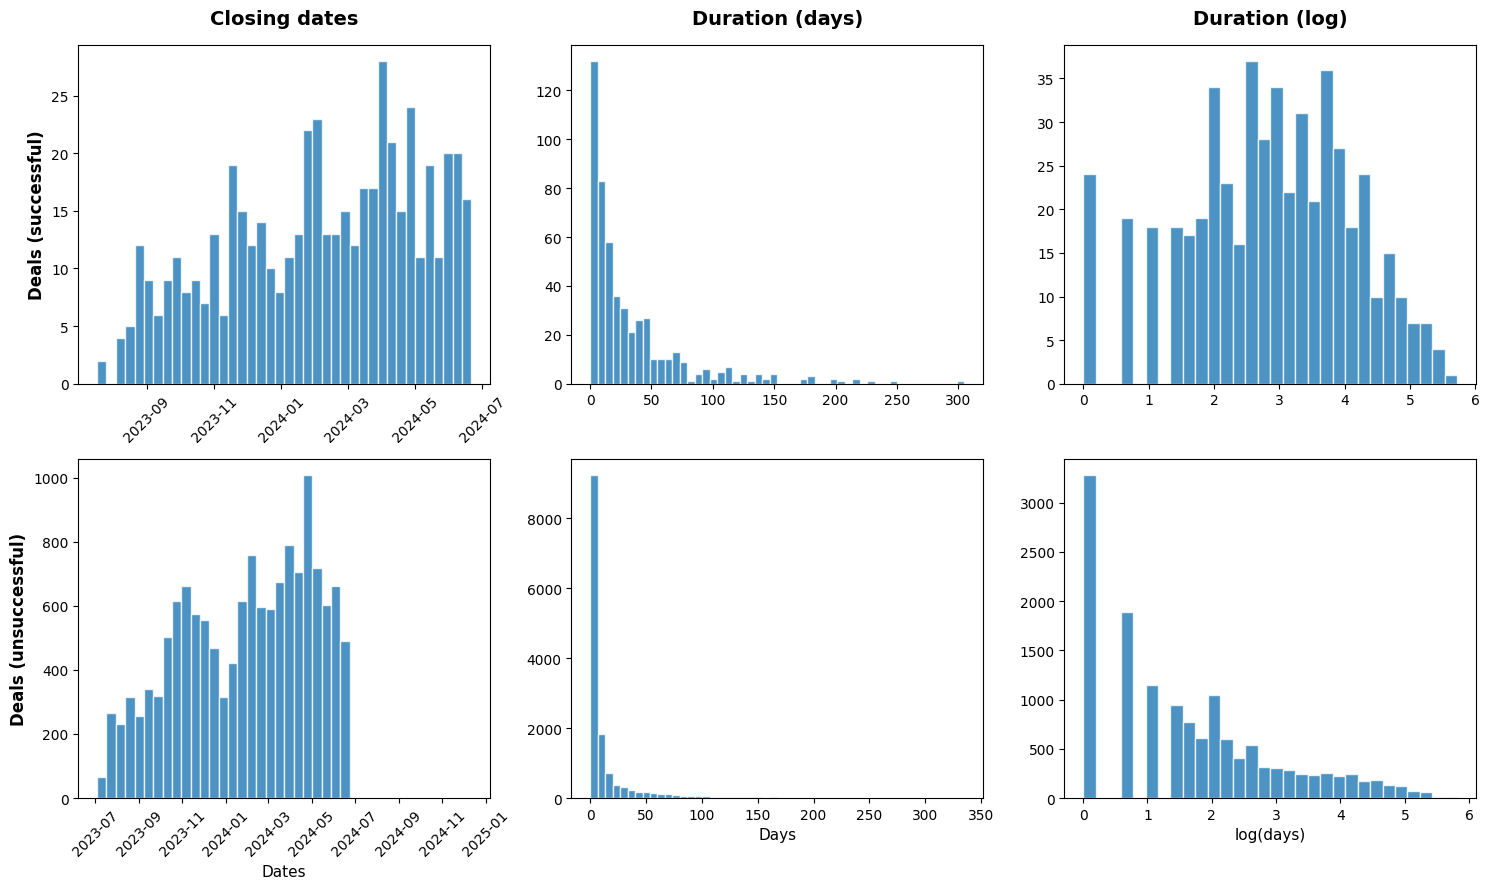

In [7]:
# Charts
plt.figure(figsize=(15, 9))

# Successful deals
plt.subplot(2, 3, 1)
plt.hist(success['closing_date'], bins=40, edgecolor='white', alpha=0.8)
plt.title('Closing dates', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Deals (successful)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
plt.hist(success['duration_days'], bins=50, edgecolor='white', alpha=0.8)
plt.title('Duration (days)', fontsize=14, fontweight='bold', pad=15)

plt.subplot(2, 3, 3)
plt.hist(success['log_duration'], bins=30, edgecolor='white', alpha=0.8)
plt.title('Duration (log)', fontsize=14, fontweight='bold', pad=15)



# Unsuccessful deals
plt.subplot(2, 3, 4)
plt.hist(failed['closing_date'], bins=40, edgecolor='white', alpha=0.8)
plt.ylabel('Deals (unsuccessful)', fontsize=12, fontweight='bold')
plt.xlabel('Dates', fontsize=11)
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
plt.hist(failed['duration_days'], bins=50, edgecolor='white', alpha=0.8)
plt.xlabel('Days', fontsize=11)

plt.subplot(2, 3, 6)
plt.hist(failed['log_duration'], bins=30, edgecolor='white', alpha=0.8)
plt.xlabel('log(days)', fontsize=11)

plt.tight_layout()
plt.show()

#### Conclusions:

- **Critical threshold — 7 days**  
  If a deal is not closed within the first week, its chance of success drops sharply. The majority of rejections occur during this period.

- **Reason** — leads are either non-targeted or lose interest at the start.

- **Successful deals are delayed**  
  The peak of closures occurs in the period **from 1 to 4 weeks**. This means that quality leads go through a longer decision-making cycle.

- **Recommendation**  
  Shift focus from "new" leads to those who **have passed the 7-day threshold**. This group represents the highest quality candidates for successful closure.

# 3. Campaign efficiency analysis:

### 3.1 Comparison of different campaigns' effectiveness in terms of lead generation and conversion rate:

In [8]:
# Count number of leads by campaign (all deals)
leads_by_campaign = deals['deal_campaign'].value_counts().reset_index() # Turns index into a regular column for later merging
leads_by_campaign.columns = ['campaign', 'leads']

# Count number of successful deals by campaign
success_by_campaign = deals[deals['stage'] == 'Payment Done']['deal_campaign'].value_counts().reset_index()
success_by_campaign.columns = ['campaign', 'success']

leads_by_campaign, success_by_campaign

(                              campaign  leads
 0    performancemax_digitalmarkt_ru_DE   2650
 1                    12.07.2023wide_DE   1664
 2                    youtube_shorts_DE   1643
 3                      02.07.23wide_DE   1080
 4             04.07.23recentlymoved_DE    752
 ..                                 ...    ...
 149                           women_DE      1
 150                           anuta_DE      1
 151                            grad_DE      1
 152                     comp_search_DE      1
 153                           marue_DE      1
 
 [154 rows x 2 columns],
                              campaign  success
 0   performancemax_digitalmarkt_ru_DE      112
 1                     02.07.23wide_DE       56
 2                   youtube_shorts_DE       53
 3                   12.07.2023wide_DE       48
 4            04.07.23recentlymoved_DE       31
 ..                                ...      ...
 62                           referral        1
 63                  05.0

In [9]:
# Merge and calculate conversion
campaign_stats = leads_by_campaign.merge(success_by_campaign, on='campaign', how='left')
campaign_stats['conversion'] = (campaign_stats['success'] / campaign_stats['leads'] * 100).round(1)

# Sort by leads and take top 10
campaign_stats = campaign_stats.sort_values('leads', ascending=False).head(10)

In [10]:
campaign_stats

,campaign,leads,success,conversion
0,performancemax_digitalmarkt_ru_DE,2650,112.0,4.2
1,12.07.2023wide_DE,1664,48.0,2.9
2,youtube_shorts_DE,1643,53.0,3.2
3,02.07.23wide_DE,1080,56.0,5.2
4,04.07.23recentlymoved_DE,752,31.0,4.1
5,03.07.23women,609,31.0,5.1
6,Dis_DE,580,30.0,5.2
7,07.07.23LAL_DE,540,28.0,5.2
8,12.09.23interests_Uxui_DE,530,27.0,5.1
9,24.09.23retargeting_DE,478,17.0,3.6


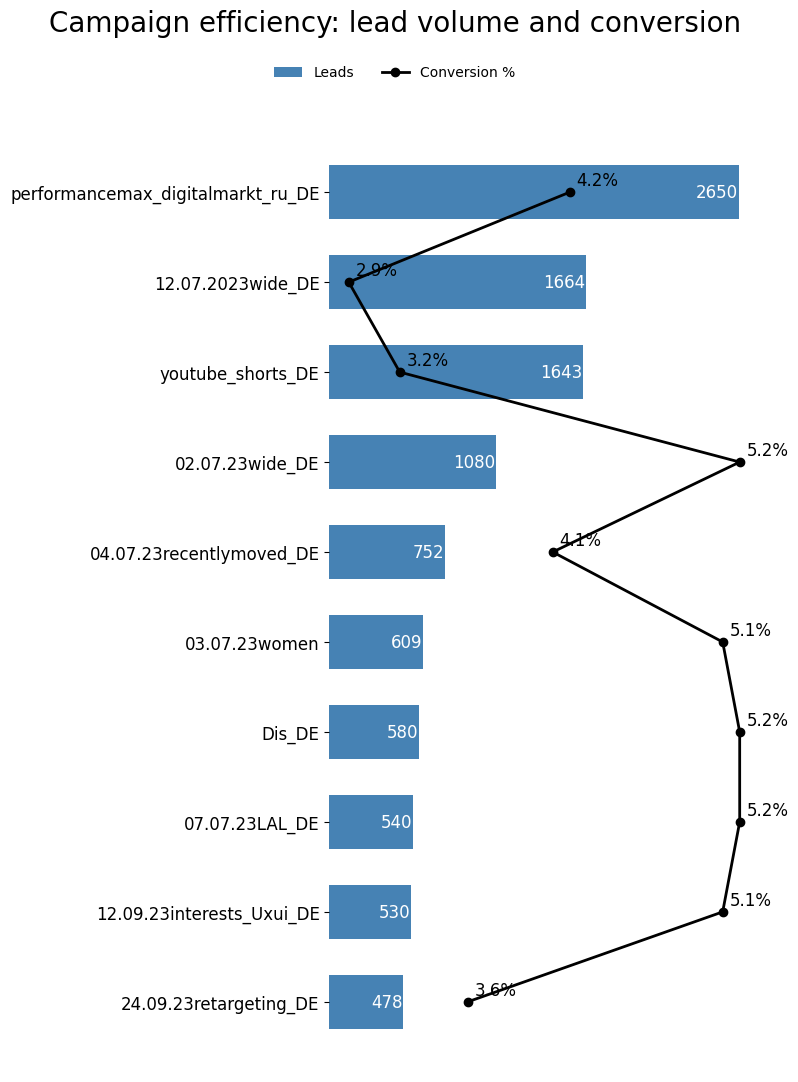

In [11]:
# sorting data
campaign_stats = campaign_stats.sort_values('leads')

fig, ax = plt.subplots(figsize=(8, 11))

y = range(len(campaign_stats))

# leads
bars = ax.barh(y, campaign_stats['leads'], color='steelblue', height=0.6)
ax.set_yticks(y)
ax.set_yticklabels(campaign_stats['campaign'], fontsize=12)

# lead labels
for i, val in enumerate(campaign_stats['leads']):
    ax.text(val - 5, i, val, va='center', ha='right', fontsize=12, color='white')

# second axis (conversion)
ax2 = ax.twiny()
line = ax2.plot(campaign_stats['conversion'], y, color='black', marker='o', linewidth=2)

# conversion labels
for i, v in enumerate(campaign_stats['conversion']):
    ax2.annotate(f'{v}%', (v, i), xytext=(5, 5), textcoords="offset points", fontsize=12)

# remove axes
ax.set_xticks([])
ax2.set_xticks([])
# remove borders
for ax_i in (ax, ax2):
    for spine in ax_i.spines.values():
        spine.set_visible(False)

# title
fig.suptitle('Campaign efficiency: lead volume and conversion', fontsize=20)

# legend
fig.legend([bars, line[0]], ['Leads', 'Conversion %'], loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('campaign_efficiency.svg', bbox_inches='tight')
plt.show()

### Conclusions

- **performancemax** — 2,650 leads, conversion 4.2%. Mass campaigns generate volume, but quality is lower.
- **Best by conversion (5.1–5.2%)** — `02.07.23wide_DE`, `women`, `Dis_DE`, `LAL_DE`, `interest_Uxui_DE`. Volume of 500–1,000 leads.
- **Weak campaigns (2.9–3.6%)** — `youtube_shorts-DE`, `12.07.2023wide-DE`, `retargeting-DE`. Low traffic quality.

### Recommendations
- Re-check the channels: especially `wide` — likely “junk” traffic.

### 3.2 Evaluation of the effectiveness of various marketing sources in generating quality leads

In [12]:
deals['source'].value_counts()

source
Facebook Ads      4832
Google Ads        4222
Organic           2589
Tiktok Ads        2049
SMM               1729
Youtube Ads       1657
CRM               1656
Bloggers          1086
Telegram posts    1001
Webinar            379
Partnership        203
Test               159
Offline              2
Name: count, dtype: int64

In [13]:
# Count number of leads by source (all deals)
leads_by_source = deals['source'].value_counts().reset_index() # reset index for merge
leads_by_source.columns = ['source', 'leads']

# Count number of successful deals by campaign
success_by_source = deals[deals['stage'] == 'Payment Done']['source'].value_counts().reset_index()
success_by_source.columns = ['source', 'success']


# Merge and calculate conversion
source_stats = leads_by_source.merge(success_by_source, on='source', how='left')
source_stats['conversion'] = (source_stats['success'] / source_stats['leads'] * 100).round(1)

# Sort by leads and take top 10
source_stats = source_stats.sort_values('leads', ascending=False).head(10)

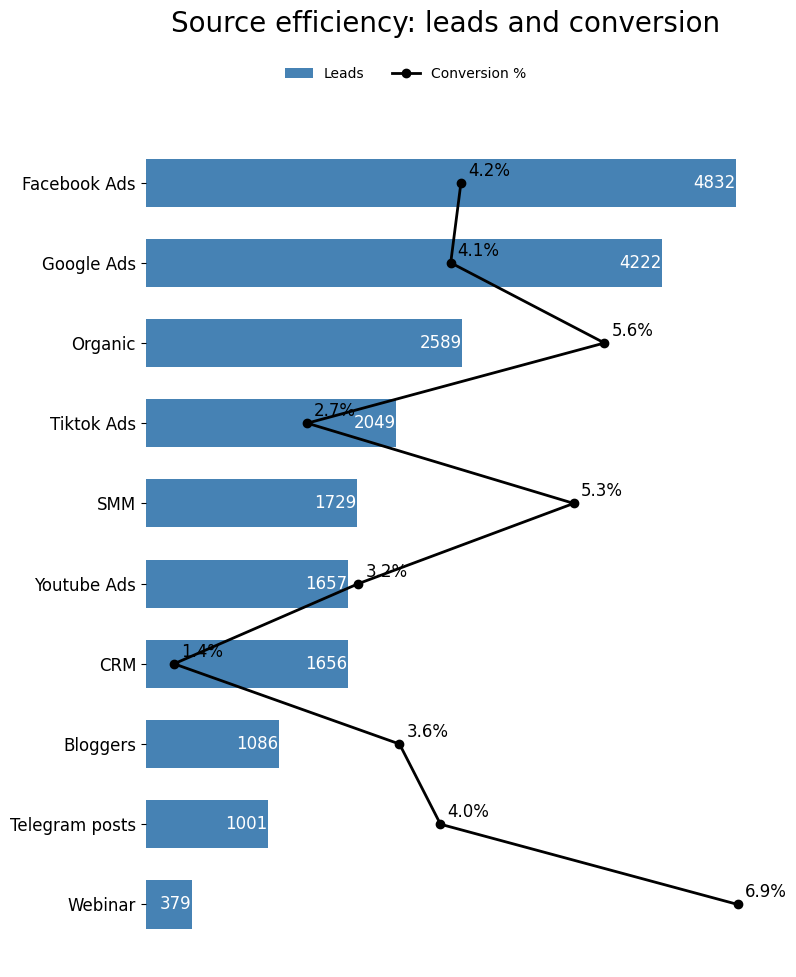

In [14]:
# sorting data
source_stats = source_stats.sort_values('leads')

fig, ax = plt.subplots(figsize=(8, 11))

y = range(len(source_stats))

# leads
bars = ax.barh(y, source_stats['leads'], color='steelblue', height=0.6)
ax.set_yticks(y)
ax.set_yticklabels(source_stats['source'], fontsize=12)

# lead labels
for i, val in enumerate(source_stats['leads']):
    ax.text(val - 5, i, val, va='center', ha='right', fontsize=12, color='white')

# second axis (conversion)
ax2 = ax.twiny()
line = ax2.plot(source_stats['conversion'], y, color='black', marker='o', linewidth=2)

# conversion labels
for i, v in enumerate(source_stats['conversion']):
    ax2.annotate(f'{v}%', (v, i), xytext=(5, 5), textcoords="offset points", fontsize=12)

# remove axes
ax.set_xticks([])
ax2.set_xticks([])
# remove borders
for ax_i in (ax, ax2):
    for spine in ax_i.spines.values():
        spine.set_visible(False)

# title
fig.suptitle('Source efficiency: leads and conversion', fontsize=20)

# legend
fig.legend([bars, line[0]], ['Leads', 'Conversion %'], loc='upper center', bbox_to_anchor=(0.45, 0.94), ncol=2, frameon=False)

plt.savefig('source_efficiency.svg')
plt.show()

In [15]:
# second graph for greater clarity

fig = px.scatter(source_stats, x='leads', y='conversion', size='leads', 
                 color='conversion', text='source', 
                 title='Source efficiency',
                 labels={'leads': 'Number of leads', 
                        'conversion': 'Conversion',
                        'color': ' '},
                        color_continuous_scale='Blues')
                    

fig.update_layout(width=1000, height=600, plot_bgcolor='white')
fig.update_traces(textposition='top center', marker=dict(sizeref=2))

fig.add_vline(x=source_stats['leads'].mean(), line_dash="dash",)

fig.add_hline(y=source_stats['conversion'].mean(), line_dash="dash")

fig.show()

### Conclusions

- Facebook/Google Ads: Generate the main volume of leads, but conversion stays at an average level.
- Organic — high quality with average volume.
- Webinar — a stable source with good conversion. Probably difficult to scale.
- SMM, Telegram posts, Bloggers — average indicators in terms of volume and conversion. Require ROI analysis.
- Youtube Ads, Tiktok Ads — low conversion with small volume. Possibly non-targeted traffic or weak creatives.
- Review CRM operations: Leads from the database show abnormally low conversion.

# 4. Analysis of sales department efficiency:

### 4.1 Evaluate the efficiency of individual deal owners and advertising campaigns in terms of number of deals processed, conversion rate, and total sales amount.

In [16]:
# Efficiency analysis by manager
# Count total number of deals by each manager
total_by_manager = deals.groupby('deal_manager')['deals_id'].count().reset_index()
total_by_manager.columns = ['deal_manager', 'deals_total']

# Count number of successful deals by each manager
successful = deals[deals['stage'] == 'Payment Done']
success_by_manager = successful.groupby('deal_manager')['deals_id'].count().reset_index()
success_by_manager.columns = ['deal_manager', 'deals_success']

# Calculate revenue by each manager
revenue_by_manager = successful.groupby('deal_manager')['offer_total_amount'].sum().reset_index()
revenue_by_manager.columns = ['deal_manager', 'revenue']

# Merge all tables
stats = total_by_manager.merge(success_by_manager, on='deal_manager', how='left')
stats = stats.merge(revenue_by_manager, on='deal_manager', how='left')

stats


/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/2127228764.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/2127228764.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/2127228764.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,deal_manager,deals_total,deals_success,revenue
0,Alice Johnson,25,0,0
1,Amy Green,66,0,0
2,Ben Hall,1345,46,344500
3,Bob Brown,337,0,0
4,Cara Iverson,1056,27,218000
5,Charlie Davis,2963,148,1065600
6,Diana Evans,1013,1,3500
7,Eva Kent,459,18,132400
8,George King,94,2,9000
9,Ian Miller,497,8,35500


In [17]:
# Fill missing values (if a manager has no successful deals)
stats['deals_success'] = stats['deals_success'].fillna(0)
stats['revenue'] = stats['revenue'].fillna(0)

# Calculate conversion
stats['conversion'] = (stats['deals_success'] / stats['deals_total'] * 100).round(1)

# Calculate average check
stats['avg_check'] = 0
for i, row in stats.iterrows():
    if row['deals_success'] > 0:
        stats.loc[i, 'avg_check'] = round(row['revenue'] / row['deals_success'], 0)

# Sort by number of successful deals and take top 15
stats = stats.sort_values('deals_success', ascending=False).head(15)

stats

,deal_manager,deals_total,deals_success,revenue,conversion,avg_check
5,Charlie Davis,2963,148,1065600,5.0,7200
21,Ulysses Adams,2165,141,1010400,6.5,7166
12,Julia Nelson,2241,93,729201,4.1,7841
17,Paula Underwood,1862,93,693000,5.0,7452
18,Quincy Vincent,1884,65,465000,3.5,7154
16,Oliver Taylor,163,50,524500,30.7,10490
15,Nina Scott,1283,46,314900,3.6,6846
2,Ben Hall,1345,46,344500,3.4,7489
22,Victor Barnes,1232,44,335900,3.6,7634
13,Kevin Parker,574,40,211400,7.0,5285


In [18]:
fig = px.scatter(stats, x='deals_success', y='revenue', size='deals_total', 
                 color='conversion', text='deal_manager', 
                 title='Manager efficiency',
                 labels={'deals_success': 'Successful deals', 
                        'revenue': 'Revenue',
                        'deals_total': 'Total deals',
                        'conversion': 'Conversion (%)',
                        'color': ' '},
                 color_continuous_scale='Blues')

fig.update_layout(width=1000, height=600, plot_bgcolor='white')
fig.update_traces(textposition='top center', marker=dict(sizeref=1))

fig.add_vline(x=stats['deals_success'].mean(), line_dash="dash")
fig.add_hline(y=stats['revenue'].mean(), line_dash="dash")

fig.show()

### Conclusions

- **Oliver Taylor** shows good conversion results with a moderate volume of leads. Perhaps he has effective work techniques that could be useful for others.
- **Victor Barnes**, **Nina Scott**, **Ben Hall**, **Cara Iverson**, **Jane Smith** show low results on both metrics. They require review and possibly need additional support or a reconsideration of their work approach.

In [19]:
# Top 10 least effective managers
deals['is_success'] = deals['stage'] == 'Payment Done'
# Grouping
manager_performance = deals.groupby('deal_manager').agg(
    deals_total=('deals_id', 'count'),
    deals_success=('is_success', 'sum')
).reset_index()

# Conversion
manager_performance['conversion'] = (manager_performance['deals_success'] / manager_performance['deals_total'] * 100).round(1)

# Sorting:
# deals (descending), conversion (descending)
manager_performance = manager_performance.sort_values(['conversion', 'deals_total'], ascending=[True, False]).head(10)

manager_performance

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/2278969898.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,deal_manager,deals_total,deals_success,conversion
19,Rachel White,871,0,0.0
3,Bob Brown,337,0,0.0
25,Yara Edwards,85,0,0.0
20,Sam Young,67,0,0.0
1,Amy Green,66,0,0.0
0,Alice Johnson,25,0,0.0
24,Xander Dean,3,0,0.0
23,Wendy Clark,2,0,0.0
26,Zachary Foster,1,0,0.0
6,Diana Evans,1013,1,0.1


### Conclusions

- **Rachel White** and **Bob Brown** — the largest volume of unrealized deals.
- **Diana Evans** — 1,013 deals with 0.1% conversion, which is comparable to having no results.
- The total volume of leads processed in this group is more than 2,500.

### Recommendations

- Conduct an audit of the work of the listed employees.
- Consider redistributing the incoming flow in favor of more effective managers.

In [20]:
# Efficiency analysis by campaign

# Count total number of deals by each campaign
total_by_campaign = deals.groupby('deal_campaign')['deals_id'].count().reset_index()
total_by_campaign.columns = ['deal_campaign', 'deals_total']

# Count number of successful deals by each campaign
successful = deals[deals['stage'] == 'Payment Done']
success_by_campaign = successful.groupby('deal_campaign')['deals_id'].count().reset_index()
success_by_campaign.columns = ['deal_campaign', 'deals_success']

# Calculate revenue by each campaign
revenue_by_campaign = successful.groupby('deal_campaign')['offer_total_amount'].sum().reset_index()
revenue_by_campaign.columns = ['deal_campaign', 'total_sales']

# Merge all tables
campaigns = total_by_campaign.merge(success_by_campaign, on='deal_campaign', how='left')
campaigns = campaigns.merge(revenue_by_campaign, on='deal_campaign', how='left')

# Fill missing values (if a campaign has no successful deals)
campaigns['deals_success'] = campaigns['deals_success'].fillna(0)
campaigns['total_sales'] = campaigns['total_sales'].fillna(0)

# Calculate conversion
campaigns['conversion'] = (campaigns['deals_success'] / campaigns['deals_total'] * 100).round(1)

# Calculate average check
campaigns['avg_check'] = 0
for i, row in campaigns.iterrows():
    if row['deals_success'] > 0:
        campaigns.loc[i, 'avg_check'] = round(row['total_sales'] / row['deals_success'], 0)

# Sort by number of deals and take top 15
campaigns = campaigns.sort_values('deals_total', ascending=False).head(15)

campaigns

,deal_campaign,deals_total,deals_success,total_sales,conversion,avg_check
118,performancemax_digitalmarkt_ru_DE,2650,112.0,839400,4.2,7495
18,12.07.2023wide_DE,1664,48.0,336400,2.9,7008
152,youtube_shorts_DE,1643,53.0,415500,3.2,7840
2,02.07.23wide_DE,1080,56.0,426400,5.2,7614
5,04.07.23recentlymoved_DE,752,31.0,190100,4.1,6132
4,03.07.23women,609,31.0,255900,5.1,8255
60,Dis_DE,580,30.0,221500,5.2,7383
8,07.07.23LAL_DE,540,28.0,243000,5.2,8679
19,12.09.23interests_Uxui_DE,530,27.0,229000,5.1,8481
40,24.09.23retargeting_DE,478,17.0,145900,3.6,8582


In [21]:
fig = px.scatter(campaigns, x='deals_total', y='deals_success', 
                 size='total_sales', text='deal_campaign', 
                 color='conversion',
                 title='Campaigns: volume vs success',
                 labels={'deals_total': 'Total deals', 
                        'deals_success': 'Successful deals',
                        'total_sales': 'Revenue',
                        'conversion': 'Conversion (%)',
                        'color': ' '},
                 color_continuous_scale='Blues')

fig.update_layout(width=1200, height=800, plot_bgcolor='white')
fig.update_traces(textposition='top center')

fig.add_vline(x=campaigns['deals_total'].mean(), line_dash="dash")
fig.add_hline(y=campaigns['deals_success'].mean(), line_dash="dash")

fig.show()

### Conclusions

- **performancemarkt_ru_DE** — top earner, average conversion.
- **02.07.23wide_DE** — low traffic, high conversion. Possibly consider scaling.
- **youtube_shorts_DE** and **12.07.2023wide_DE** — high traffic, low conversion. Review settings.
- **retargeting_DE** — good quality, small reach. Expand.
- **webinar1604** and other webinars — not working. Turn off.

# 5. Analysis of payments and products:

### 5.1 Study the distribution of payment types and their impact on deal success.

In [22]:
deals['payment_type'].unique()

[NaN, 'One Payment', 'Recurring Payments', 'Unknown', 'Reservation']
Categories (4, object): ['One Payment', 'Recurring Payments', 'Reservation', 'Unknown']

In [23]:
# Filter and count
clean = deals[deals['payment_type'].notna()]
clean = clean[clean['payment_type'] != 'nan']
clean = clean[clean['payment_type'] != 'Unknown']

total = clean.groupby('payment_type').size()
success = clean[clean['stage'] == 'Payment Done'].groupby('payment_type').size()

stats = pd.DataFrame({'total': total, 'success': success}).fillna(0)
stats['conversion'] = (stats['success'] / stats['total'] * 100).round(1)
stats = stats.sort_values('total', ascending=False)

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/2128239305.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/2128239305.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/4015307937.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



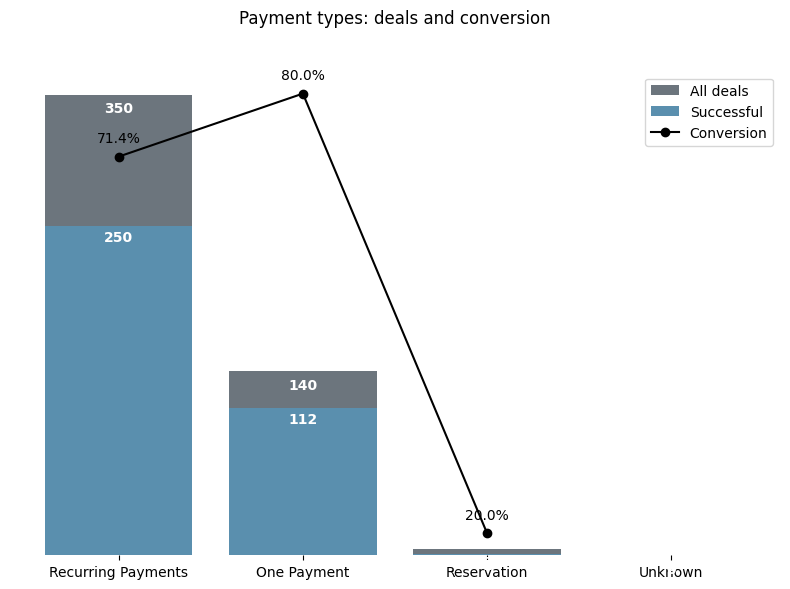

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Bars: all deals and successful
bars1 = ax.bar(stats.index, stats['total'], color='#6c757d', label='All deals')
bars2 = ax.bar(stats.index, stats['success'], color='#5a8fae', label='Successful')

# Remove axes and borders
ax.set_xticklabels(stats.index)
ax.set_yticks([])
ax.spines.clear()

# Conversion line
ax2 = ax.twinx()
line = ax2.plot(stats.index, stats['conversion'], 'o-', color='black', label='Conversion')
ax2.set_yticks([])
ax2.spines.clear()

# Legend
ax.legend(handles=[bars1, bars2, line[0]], labels=['All deals', 'Successful', 'Conversion'], loc='upper right')

# Numbers on bars
for i, v in enumerate(stats['total']):
    ax.text(i, v - 5, str(int(v)), ha='center', va='top', color='white', fontweight='bold')
for i, v in enumerate(stats['success']):
    ax.text(i, v - 3, str(int(v)), ha='center', va='top', color='white', fontweight='bold')
for i, v in enumerate(stats['conversion']):
    ax2.text(i, v + 2, f'{v}%', ha='center')

plt.title('Payment types: deals and conversion', pad=35)
plt.tight_layout()
plt.show()

#### Conclusions

- One-time payments — the highest conversion  
- Recurring payments (subscriptions) — leaders in number of deals and total profit  

Recommendation:  
Remove Reservation as an ineffective payment type.

### 5.2 Analyze the popularity and success of various products and education types.

In [25]:
# Products
total = deals['product'].value_counts()
success = deals[deals['stage'] == 'Payment Done']['product'].value_counts()
prod = pd.DataFrame({'total': total, 'success': success}).fillna(0)
prod['conversion'] = (prod['success'] / prod['total'] * 100).round(1)
prod = prod.sort_values('total', ascending=False)
prod

,total,success,conversion
product,,,
Digital Marketing,1994,474,23.8
UX/UI Design,1022,229,22.4
Web Developer,575,137,23.8
Find yourself in IT,4,1,25.0
Data Analytics,1,0,0.0


/var/folders/b2/7j01xs_d4yvgcqyrhxv8x00w0000gn/T/ipykernel_36061/3818090262.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



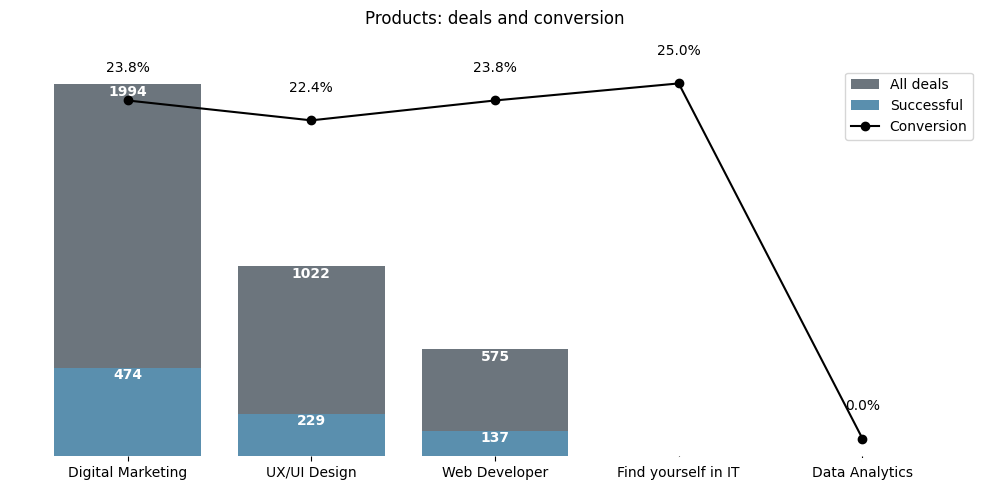

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(prod.index, prod['total'], color='#6c757d', label='All deals')
bars2 = ax.bar(prod.index, prod['success'], color='#5a8fae', label='Successful')
ax.set_xticklabels(prod.index)
ax.set_yticks([])
ax.spines.clear()

ax2 = ax.twinx()
line = ax2.plot(prod.index, prod['conversion'], 'o-', color='black', label='Conversion')
ax2.set_yticks([])
ax2.spines.clear()

# Combine legend
ax.legend(handles=[bars1, bars2, line[0]], labels=['All deals', 'Successful', 'Conversion'], loc='upper right')

# Numbers
for i, v in enumerate(prod['total']):
    ax.text(i, v - 5, str(int(v)), ha='center', va='top', color='white', fontweight='bold')
for i, v in enumerate(prod['success']):
    ax.text(i, v - 3, str(int(v)), ha='center', va='top', color='white', fontweight='bold')
for i, v in enumerate(prod['conversion']):
    ax2.text(i, v + 2, f'{v}%', ha='center')

plt.title('Products: deals and conversion', pad=30)
plt.tight_layout()
plt.show()

### Conclusions:

- **Conversion for all products is approximately the same** — in the range of 22–24%, except for two outliers (Find yourself in IT / Data Analytics). For these products, **more data is needed**.  
It is not yet possible to confirm success nor draw a conclusion about ineffectiveness.

In [27]:
# Analysis of education types
total = deals['education_type'].value_counts()
success = deals[deals['stage'] == 'Payment Done']['education_type'].value_counts()
edu = pd.DataFrame({'total': total, 'success': success}).fillna(0)
edu['conversion'] = (edu['success'] / edu['total'] * 100).round(1)
edu = edu.sort_values('total', ascending=False)
total

education_type
Morning    3028
Evening     411
Name: count, dtype: int64

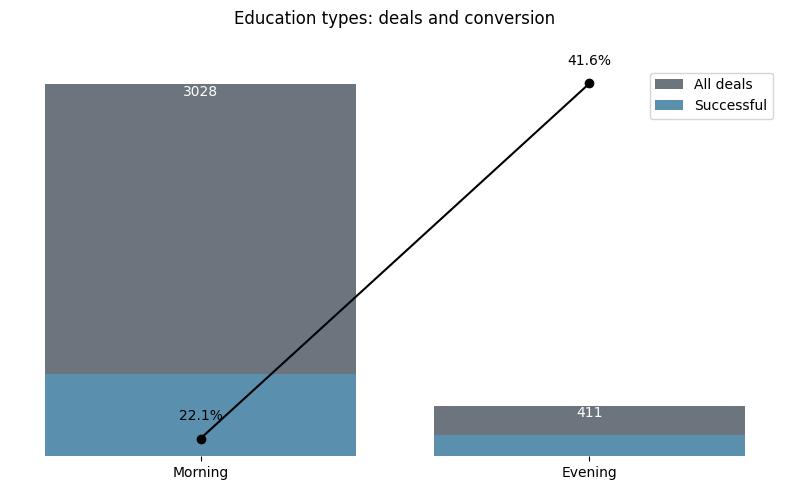

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(edu.index, edu['total'], color='#6c757d')
ax.bar(edu.index, edu['success'], color='#5a8fae')
ax.set_yticks([])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax2 = ax.twinx()
ax2.plot(edu.index, edu['conversion'], 'o-', color='black')
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

for i, v in enumerate(edu['total']):
    ax.text(i, v-3, str(int(v)), ha='center', va='top', color='white')
for i, v in enumerate(edu['conversion']):
    ax2.text(i, v+1, f'{v}%', ha='center')

ax.legend(['All deals', 'Successful', 'Conversion'], loc='upper right')
plt.title('Education types: deals and conversion', pad=30)
plt.tight_layout()
plt.show()

### Conclusions

- **Morning (morning classes)** — leader in volume (3,028 deals), conversion **22.1%**
- **Evening (evening classes)** — smaller volume (411 deals), but conversion **41.6%** — almost 2 times higher

- **Evening classes** are significantly more effective in terms of conversion, but have a small reach.
- **Morning classes** bring a massive flow, but the quality is lower.
- Possible reasons:
  - People who work study in the evenings — a more motivated audience
  - In the morning — a broader but less targeted audience